# 🏬 Dark Store Operations Simulator
## Notebook 1 — Exploratory Data Analysis & Business Health

**Author:** Sumit Kumar Gupta

**Notebook purpose:** Establish a validated, trustworthy foundation of operational KPIs and exploratory insights that all downstream analysis (forecasting, segmentation, optimization) will build on.

---

## 1. Business Objective

**Context.** The company operates a network of *dark stores* (delivery-only micro-fulfilment centers) across major Indian cities, promising customers delivery within a **30-minute SLA**. Operations leadership needs a single, trustworthy view of how the network is performing before any deeper modeling (demand forecasting, inventory optimization, routing) is attempted.

**Business problem this notebook answers:**
> *"Is the dark store network healthy — and where exactly is it breaking down?"*

Specifically, this notebook is designed to answer:

1. **Revenue health** — How much revenue are we generating, and where is it concentrated (city / store / category)?
2. **Fulfilment health** — Are we meeting the 30-minute SLA, and which stage of the fulfilment pipeline (pick → pack → dispatch → deliver) is the bottleneck?
3. **Reliability health** — How often do stockouts and cancellations occur, and do they cluster around specific conditions (e.g. peak hours, high-utilization stores)?
4. **Customer experience health** — How does operational performance (SLA breaches, stockouts) translate into customer ratings?
5. **Data trustworthiness** — Is the underlying data clean, are our KPI calculations correct, and which of the supplied files can actually be joined together — so that every downstream decision is built on a reliable, defensible number?

**Why this matters to the business:** SLA breaches and stockouts directly erode customer trust and repeat-purchase rate, while revenue and store-level variance point to where operational investment (staffing, inventory, store placement) will have the highest ROI. This notebook produces the diagnostic evidence base for those decisions — it does not yet prescribe solutions (that is left to later notebooks on forecasting and optimization).

**Notebook roadmap:**

| Section | What it covers |
|---|---|
| 2 | Dataset assumptions, data sources, and which files are actually usable together |
| 3 | Data loading |
| 4 | Data quality report (missing values, duplicates, validation, cross-file join checks) |
| 5 | Data dictionary — business meaning of key columns |
| 6 | KPI calculation & validation (Python vs. SQL cross-check) |
| 7 | Distribution analysis (revenue, SLA, stockouts, cancellations) |
| 8 | Business performance breakdown: city / category / store / pipeline / peak hours / capacity / delivery distance |
| 9 | Correlation heatmap of KPI relationships |
| 10 | Executive summary — top 10 business findings |

## 2. Dataset Assumptions & Data Sources

This is a **synthetic operational dataset** built to resemble a real dark-store network. Eight files were supplied. Before analyzing anything, we document what each file is, how it relates to the others, and — critically — **which files can actually be joined together**, since assuming a join key exists without checking it is a common source of silently wrong analysis.

### 2.1 Files used in this notebook

| File | Grain | Key | Used for |
|---|---|---|---|
| `orders.csv` | 1 row per customer order | `order_id` (PK), `store_id` (FK) | Core fact table — revenue, SLA, stockouts, cancellations, ratings |
| `inventory.csv` | 1 row per store × category | `store_id` + `category` | Stock levels, reorder risk |
| `dark_stores.csv` | 1 row per store | `store_id` (PK) | Store metadata — city, picker/rider headcount, store size |
| `capacity.csv` | 1 row per store | `store_id` (PK) | Daily order capacity vs. actual load → utilization % |

`orders.store_id` and `dark_stores.store_id` / `capacity.store_id` use identical IDs (verified in Section 4.4), so these three files merge cleanly and are used together in Section 8.6.

### 2.2 Files checked but **not** merged into the core analysis (with reasons)

| File | Reason |
|---|---|
| `deliveries.csv` | Rider-leg-level data (`order_id` values `ORD1`–`ORD9999`). Its `order_id` values **do not overlap at all** with `orders.csv` (`ORD100000`+) — confirmed in Section 4.4. It cannot be joined to the order-level fact table with the keys provided, so it is analyzed **independently** in Section 8.7 rather than silently (and incorrectly) merged on a shared column name. |
| `products.csv`, `aisles.csv`, `departments.csv` | These form an Instacart-style product catalog (49,688 SKUs, aisle/department hierarchy). `orders.csv` uses a flat 7-value `category` field (Dairy, Snacks, etc.) with no product- or aisle-level key, so there is no valid join between the catalog and the order fact table. They are out of scope for this notebook and are not loaded. |

### 2.3 Business-rule assumptions baked into `orders.csv`

| Assumption | Detail |
|---|---|
| SLA definition | An order **breaches SLA** if `total_fulfillment_time_min > 30` |
| Fulfilment pipeline | `total_fulfillment_time_min = pick_time_min + pack_time_min + dispatch_time_min + delivery_time_min` |
| Peak hours | Flagged via `is_peak_hour`; modeled with higher revenue, higher stockout risk, and longer fulfilment times — mirroring real demand-surge dynamics |
| Stockouts / SLA breaches → cancellations | A stockout or SLA breach *increases* the probability of order cancellation (causal simulation, not just correlation) |
| Ratings | Customer rating is modeled as a function of SLA breach / stockout / cancellation, plus noise — i.e. **operational failures suppress ratings**, as in reality |

⚠️ **This is simulated data.** Absolute figures (revenue, ratings) should not be interpreted as real business performance — the *relationships* and *analysis methodology* are what would transfer to a production dataset. The exact scale (row counts, missingness, duplicates) is **verified empirically in Section 4**, not assumed — we don't want to hand-wave a "typical messy dataset" narrative if the data we actually received doesn't match it.

## 3. Setup

In [6]:
import os

print("Current folder:")
print(os.listdir("."))

print("\nParent folder:")
print(os.listdir(".."))

Current folder:
['2.3 intro.xlsx', 'Python ChapterWise Notes', 'complete_project_guide_step_by_step.html', 'startup mails.pdf', '15.Array Extra class codes.cpp', 'Multifunctional nanocarriers notes (1).pdf', 'WhatsApp Image 2026-07-03 at 11.38.56.jpeg', 'photo_2024-12-25_12-52-27_7457507013472288788.jpg', '5.5 data-types-string-varchar-char-enum.pdf', '8.5 adding a date table using Power Query (1).pdf', 'The Show Goes On! - Krzysztof Domaradzki #PiyushGamingWorld.jpeg', '1.1 How Can Learning Excel Help You in Your Career.mp4', 'WhatsApp Image 2026-02-06 at 00.27.14.jpeg', 'tumor targeting strategies (1).pdf', 'clark-tibbs-oqStl2L5oxI-unsplash.jpg', '5.12 movies-db-movies.csv', 'Adobe Scan 27 Dec 2025.pdf', 'Average_AveragexCount_Distinctcount_Function_85.mp4', '2_6_retrieve_data_using_numeric_query_between_in_order_b.pdf', 'WhatsApp Image 2026-07-03 at 11.38.49 (1).jpeg', 'SaaS-Sales.csv', 'photo_2024-12-25_17-40-49_7456765272620269620 (1).jpg', 'ELITE_AI_PORTFOLIO_4_PROJECTS (1).md', 

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sqlite3
import os

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries loaded")

Libraries loaded


### 3.1 Load Data

To keep this notebook portable (runnable on any machine, not just the original author's laptop), we search a small list of likely data locations rather than hardcoding an absolute path. Place the five CSVs in a `data/` folder next to this notebook (or edit `DATA_DIR` directly).

In [13]:
def find_data_dir():
    # Search common relative locations for the data folder so the notebook
    # doesn't depend on one person's absolute file path.
    candidates = ["data", "./data", "../data", "."]
    required = ["orders.csv", "inventory.csv"]
    for c in candidates:
        if all(os.path.exists(os.path.join(c, f)) for f in required):
            return c
    raise FileNotFoundError(
        "Could not find orders.csv / inventory.csv in ./data, ../data, or the "
        "current folder. Place the data files in a 'data/' folder next to this "
        "notebook, or set DATA_DIR manually below."
    )

import os


DATA_DIR = "/Users/sumitkumargupta/Desktop/5_project/01_Data/"

print("Using DATA_DIR:", DATA_DIR)

if not os.path.exists(DATA_DIR):

    raise FileNotFoundError(f"Data folder not found: {DATA_DIR}")

Using DATA_DIR: /Users/sumitkumargupta/Desktop/5_project/01_Data/


In [14]:
orders = pd.read_csv(
    os.path.join(DATA_DIR, "orders.csv"),
    parse_dates=["order_timestamp"]
)

inventory = pd.read_csv(os.path.join(DATA_DIR, "inventory.csv"))
dark_stores = pd.read_csv(os.path.join(DATA_DIR, "dark_stores.csv"))
capacity = pd.read_csv(os.path.join(DATA_DIR, "capacity.csv"))
deliveries = pd.read_csv(os.path.join(DATA_DIR, "deliveries.csv"))

print("Orders Shape:      ", orders.shape)
print("Inventory Shape:   ", inventory.shape)
print("Dark Stores Shape: ", dark_stores.shape)
print("Capacity Shape:    ", capacity.shape)
print("Deliveries Shape:  ", deliveries.shape)

Orders Shape:       (25000, 19)
Inventory Shape:    (56, 7)
Dark Stores Shape:  (8, 6)
Capacity Shape:     (8, 4)
Deliveries Shape:   (50000, 5)


In [15]:
orders.head()

,order_id,store_id,city,category,order_timestamp,day_of_week,order_hour,is_peak_hour,pick_time_min,pack_time_min,dispatch_time_min,delivery_time_min,total_fulfillment_time_min,sla_breached,stockout_flag,cancelled_flag,revenue_inr,items_count,customer_rating
0,ORD100000,DS_Mumbai_BKC,Mumbai,Staples,2024-01-13 14:15:00,Saturday,14,0,7.00,2.90,2.30,25.60,37.80,1,0,0,"1,357.27",11,3.60
1,ORD100001,DS_Mumbai_BKC,Mumbai,Personal Care,2024-10-29 19:02:00,Tuesday,19,1,9.50,4.60,2.40,21.70,38.20,1,1,1,969.00,1,3.90
2,ORD100002,DS_Delhi_Lajpat,Delhi,Frozen,2024-11-28 23:26:00,Thursday,23,0,5.10,2.50,2.10,8.40,18.10,0,0,0,"1,109.97",1,3.50
3,ORD100003,DS_Delhi_CP,Delhi,Dairy,2024-12-23 19:21:00,Monday,19,1,8.90,2.00,2.20,19.50,32.60,1,0,0,481.73,6,3.10
4,ORD100004,DS_Mumbai_BKC,Mumbai,Staples,2024-07-13 09:22:00,Saturday,9,1,12.90,2.80,2.00,16.90,34.60,1,0,0,"1,134.26",1,3.50


## 4. Data Quality Report

Before trusting a single KPI, we validate the raw data: schema, missing values, duplicates, and logical consistency (e.g. does the fulfilment-time breakdown actually sum to the total?). We also check whether the auxiliary files can genuinely be joined to `orders` — a join check is a data-quality check too.

In [16]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   order_id                    25000 non-null  str           
 1   store_id                    25000 non-null  str           
 2   city                        25000 non-null  str           
 3   category                    25000 non-null  str           
 4   order_timestamp             25000 non-null  datetime64[us]
 5   day_of_week                 25000 non-null  str           
 6   order_hour                  25000 non-null  int64         
 7   is_peak_hour                25000 non-null  int64         
 8   pick_time_min               25000 non-null  float64       
 9   pack_time_min               25000 non-null  float64       
 10  dispatch_time_min           25000 non-null  float64       
 11  delivery_time_min           25000 non-null  float64       
 12  t

### 4.1 Missing Values

In [17]:
missing = orders.isnull().sum()
missing_pct = (missing / len(orders) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})

missing_report[missing_report["Missing Count"] > 0]

,Missing Count,Missing %


> **Finding:** Zero missing values across all 19 columns of `orders.csv` — the table above is empty because no column has a missing-value count greater than zero. This particular extract of the synthetic dataset arrived clean. That's a genuinely useful finding to state explicitly (rather than assume): it means we do **not** need an imputation strategy for `customer_rating` or any other field in this analysis. In a real production pipeline we would not expect this — we'd still run this exact check on every refresh, since silently trusting "last time it was clean" is how missing-data bugs slip into dashboards.

### 4.2 Duplicate Records

In [18]:
full_duplicates = orders.duplicated().sum()
id_duplicates = orders.duplicated(subset=["order_id"]).sum()

print(f"Fully duplicated rows: {full_duplicates}")
print(f"Duplicate order_id values: {id_duplicates}")

Fully duplicated rows: 0
Duplicate order_id values: 0


> **Finding:** Zero fully-duplicated rows and zero duplicate `order_id` values. We still run `drop_duplicates()` below as a defensive, idempotent step — in a production pipeline, duplicates typically come from retried API calls or webhook re-deliveries, and keeping this line in means the notebook stays correct even if a future data refresh isn't as clean as this one.

In [19]:
orders = orders.drop_duplicates().reset_index(drop=True)
print("Orders shape after de-duplication step:", orders.shape)

Orders shape after de-duplication step: (25000, 19)


### 4.3 Logical / Referential Validation

We check that the data is internally consistent — not just "non-null", but *correct* — including whether `orders.store_id` actually resolves against the store master file.

In [20]:
# Check 1: does the fulfilment-time breakdown sum to the reported total?
recomputed_total = (
    orders["pick_time_min"] + orders["pack_time_min"] +
    orders["dispatch_time_min"] + orders["delivery_time_min"]
)
time_mismatch = (recomputed_total.round(1) != orders["total_fulfillment_time_min"].round(1)).sum()

# Check 2: is sla_breached consistent with the 30-minute rule?
expected_breach = (orders["total_fulfillment_time_min"] > 30).astype(int)
sla_mismatch = (expected_breach != orders["sla_breached"]).sum()

# Check 3: are flag columns strictly binary?
flag_cols = ["sla_breached", "stockout_flag", "cancelled_flag", "is_peak_hour"]
non_binary = {c: sorted(orders[c].unique()) for c in flag_cols if not set(orders[c].unique()).issubset({0, 1})}

# Check 4: any negative revenue or negative time values?
negative_values = {
    "revenue_inr": (orders["revenue_inr"] < 0).sum(),
    "total_fulfillment_time_min": (orders["total_fulfillment_time_min"] < 0).sum(),
}

# Check 5: every store_id maps to exactly one city?
store_city_check = orders.groupby("store_id")["city"].nunique()
inconsistent_stores = (store_city_check > 1).sum()

# Check 6: does every store_id in orders exist in the dark_stores master file?
orphan_stores = (~orders["store_id"].isin(dark_stores["store_id"])).sum()

validation_report = pd.DataFrame({
    "Check": [
        "Fulfilment time components sum to total",
        "sla_breached matches 30-min rule",
        "Flag columns are strictly binary",
        "No negative revenue / time values",
        "Every store maps to exactly one city",
        "Every orders.store_id exists in dark_stores.csv",
    ],
    "Result": [
        "PASS" if time_mismatch == 0 else f"FAIL ({time_mismatch} rows)",
        "PASS" if sla_mismatch == 0 else f"FAIL ({sla_mismatch} rows)",
        "PASS" if not non_binary else f"FAIL {non_binary}",
        "PASS" if sum(negative_values.values()) == 0 else f"FAIL {negative_values}",
        "PASS" if inconsistent_stores == 0 else f"FAIL ({inconsistent_stores} stores)",
        "PASS" if orphan_stores == 0 else f"FAIL ({orphan_stores} rows)",
    ]
})

validation_report

,Check,Result
0,Fulfilment time components sum to total,PASS
1,sla_breached matches 30-min rule,PASS
2,Flag columns are strictly binary,PASS
3,No negative revenue / time values,PASS
4,Every store maps to exactly one city,PASS
5,Every orders.store_id exists in dark_stores.csv,PASS


> **Finding:** All six structural validation checks pass. The fulfilment-time breakdown is internally consistent, SLA flags match the stated business rule, all binary flags are clean, there are no impossible negative values, the store→city mapping is stable, and every `store_id` in `orders.csv` resolves against the `dark_stores.csv` master file. **The dataset is fit for KPI calculation, and it is safe to enrich `orders` with `dark_stores`/`capacity` in Section 8.6.**

### 4.4 Secondary File Quality & Join Feasibility

We apply the same rigor to the remaining files, and explicitly test the join assumption for `deliveries.csv` that Section 2.2 flagged as suspect — this is the check that justifies treating it as a standalone dataset instead of merging it in.

In [21]:
# inventory.csv
inv_missing = inventory.isnull().sum().sum()
inv_dupe_keys = inventory.duplicated(subset=["store_id", "category"]).sum()

# dark_stores.csv / capacity.csv — one row per store expected
ds_dupe = dark_stores.duplicated(subset=["store_id"]).sum()
cap_dupe = capacity.duplicated(subset=["store_id"]).sum()
ds_cap_key_match = set(dark_stores["store_id"]) == set(capacity["store_id"])

# deliveries.csv — test the join assumption directly
deliv_missing = deliveries.isnull().sum().sum()
order_id_overlap = len(set(deliveries["order_id"]) & set(orders["order_id"]))

secondary_report = pd.DataFrame({
    "Check": [
        "inventory.csv: missing values",
        "inventory.csv: duplicate (store_id, category) keys",
        "dark_stores.csv: duplicate store_id",
        "capacity.csv: duplicate store_id",
        "dark_stores.csv and capacity.csv cover the same store_id set",
        "deliveries.csv: missing values",
        "deliveries.csv order_id overlaps with orders.csv order_id",
    ],
    "Result": [
        "PASS" if inv_missing == 0 else f"FAIL ({inv_missing} cells)",
        "PASS" if inv_dupe_keys == 0 else f"FAIL ({inv_dupe_keys} rows)",
        "PASS" if ds_dupe == 0 else f"FAIL ({ds_dupe} rows)",
        "PASS" if cap_dupe == 0 else f"FAIL ({cap_dupe} rows)",
        "PASS" if ds_cap_key_match else "FAIL (store_id sets differ)",
        "PASS" if deliv_missing == 0 else f"FAIL ({deliv_missing} cells)",
        f"NOT JOINABLE — {order_id_overlap} of {len(deliveries):,} order_ids overlap",
    ]
})

secondary_report

,Check,Result
0,inventory.csv: missing values,PASS
1,"inventory.csv: duplicate (store_id, category) ...",PASS
2,dark_stores.csv: duplicate store_id,PASS
3,capacity.csv: duplicate store_id,PASS
4,dark_stores.csv and capacity.csv cover the sam...,PASS
5,deliveries.csv: missing values,PASS
6,deliveries.csv order_id overlaps with orders.c...,"NOT JOINABLE — 0 of 50,000 order_ids overlap"


> **Finding:** `inventory.csv`, `dark_stores.csv`, and `capacity.csv` are clean and consistently keyed on `store_id`, confirming they can be safely merged onto `orders` in Section 8.6. `deliveries.csv`, however, has **zero overlapping `order_id` values** with `orders.csv` (it uses a separate `ORD1`–`ORD9999` numbering scheme, while `orders.csv` uses `ORD100000`+) — this confirms the Section 2.2 assumption and rules out merging it into the core fact table. We analyze it as an independent dataset in Section 8.7 instead of forcing an invalid join, which would silently produce `NaN`-filled or duplicated rows.

## 5. Data Dictionary — Business Meaning of Key Columns

**`orders.csv`** (core fact table, one row per order):

| Column | Type | Business Meaning |
|---|---|---|
| `order_id` | string | Unique identifier for a customer order |
| `store_id` | category | The specific dark store that fulfilled the order (FK → `dark_stores.csv`, `capacity.csv`) |
| `city` | category | City where the order was fulfilled (5 cities in this extract) |
| `category` | category | Product category of the order (Dairy, Snacks, Beverages, Frozen, Staples, Personal Care, Fruits & Veg) |
| `order_timestamp` | datetime | When the order was placed — drives peak-hour and seasonality analysis |
| `day_of_week`, `order_hour` | category / int | Derived time fields for demand-pattern analysis |
| `is_peak_hour` | binary | 1 if the order was placed during a peak demand window |
| `pick_time_min` / `pack_time_min` / `dispatch_time_min` / `delivery_time_min` | float | Minutes spent in each stage of the fulfilment pipeline |
| `total_fulfillment_time_min` | float | Sum of all four stages — the metric the 30-min SLA is measured against |
| `sla_breached` | binary | 1 if `total_fulfillment_time_min > 30` — the core reliability metric |
| `stockout_flag` | binary | 1 if the order was affected by an item being out of stock |
| `cancelled_flag` | binary | 1 if the order was cancelled |
| `revenue_inr` | float | Order value in ₹ — the core revenue metric |
| `items_count` | int | Number of items in the order |
| `customer_rating` | float (1–5) | Post-delivery customer satisfaction score |

**`inventory.csv`** (one row per store × category): `max_capacity`, `current_stock`, `reorder_point`, `turnover_rate`, and `below_reorder` (binary reorder-risk flag).

**`dark_stores.csv`** (one row per store): `picker_count`, `rider_count`, `store_size_sqm` — staffing and footprint context for each store.

**`capacity.csv`** (one row per store): `max_daily_capacity`, `avg_daily_orders`, `utilization_percent` — how loaded each store is relative to its design capacity.

**`deliveries.csv`** (one row per delivery leg, **not joinable to `orders`** — see Section 4.4): `rider_id`, `distance_km`, `delivery_time_min`, `sla_breached`. Used only as an independent rider-level check in Section 8.7. Note its `sla_breached` is defined per delivery leg and is **not the same population** as `orders.sla_breached` — the two should never be averaged together.

**Why these matter together:** `total_fulfillment_time_min` is the operational metric that drives `sla_breached`, which — along with `stockout_flag` and `cancelled_flag` — is what ultimately drives `customer_rating`. This chain (**ops performance → reliability → customer experience**) is the backbone of the analysis that follows, and Sections 8.6–8.7 extend it one layer further back into *why* fulfilment time varies (store load, delivery distance).

## 6. KPI Calculation & Validation

We calculate the headline business KPIs in pandas, then **independently recompute them in SQL** against the same data. If both approaches agree, we can trust the numbers going into every chart below — this is a standard "trust but verify" pattern before KPIs go into an executive dashboard.

### 6.1 KPIs in Python

In [22]:
kpi_python = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Total Revenue (INR)",
        "Average Order Value (INR)",
        "SLA Breach %",
        "Stockout %",
        "Cancellation %",
        "Average Rating",
    ],
    "Value": [
        len(orders),
        round(orders["revenue_inr"].sum(), 2),
        round(orders["revenue_inr"].mean(), 2),
        round(orders["sla_breached"].mean() * 100, 2),
        round(orders["stockout_flag"].mean() * 100, 2),
        round(orders["cancelled_flag"].mean() * 100, 2),
        round(orders["customer_rating"].mean(), 2),
    ]
})

kpi_python

,Metric,Value
0,Total Orders,"25,000.00"
1,Total Revenue (INR),"24,162,205.20"
2,Average Order Value (INR),966.49
3,SLA Breach %,62.81
4,Stockout %,15.17
5,Cancellation %,6.08
6,Average Rating,3.89


### 6.2 Same KPIs Re-derived in SQL

We load the (de-duplicated) dataframe into an in-memory SQLite database and compute the identical metrics with plain SQL — a different execution engine and syntax, so agreement gives real confidence the numbers aren't a pandas-specific bug.

In [23]:
conn = sqlite3.connect(":memory:")
orders.to_sql("orders", conn, index=False, if_exists="replace")

sql_query = '''
SELECT
    COUNT(*)                                   AS total_orders,
    ROUND(SUM(revenue_inr), 2)                 AS total_revenue,
    ROUND(AVG(revenue_inr), 2)                 AS avg_order_value,
    ROUND(AVG(sla_breached) * 100, 2)          AS sla_breach_pct,
    ROUND(AVG(stockout_flag) * 100, 2)         AS stockout_pct,
    ROUND(AVG(cancelled_flag) * 100, 2)        AS cancellation_pct,
    ROUND(AVG(customer_rating), 2)             AS avg_rating
FROM orders
'''

kpi_sql = pd.read_sql(sql_query, conn)
kpi_sql

,total_orders,total_revenue,avg_order_value,sla_breach_pct,stockout_pct,cancellation_pct,avg_rating
0,25000,"24,162,205.20",966.49,62.81,15.17,6.08,3.89


### 6.3 Cross-Check: Python vs. SQL

In [24]:
python_values = kpi_python["Value"].tolist()
sql_values = kpi_sql.iloc[0].tolist()

comparison = pd.DataFrame({
    "Metric": kpi_python["Metric"],
    "Python": python_values,
    "SQL": sql_values,
})
comparison["Match"] = np.isclose(comparison["Python"], comparison["SQL"], atol=0.01)

comparison

,Metric,Python,SQL,Match
0,Total Orders,"25,000.00","25,000.00",True
1,Total Revenue (INR),"24,162,205.20","24,162,205.20",True
2,Average Order Value (INR),966.49,966.49,True
3,SLA Breach %,62.81,62.81,True
4,Stockout %,15.17,15.17,True
5,Cancellation %,6.08,6.08,True
6,Average Rating,3.89,3.89,True


In [25]:
assert comparison["Match"].all(), "KPI mismatch between Python and SQL — investigate before proceeding!"
print("All KPIs validated: Python and SQL calculations agree exactly.")

All KPIs validated: Python and SQL calculations agree exactly.


> **Finding:** All 7 headline KPIs match exactly between the pandas and SQL calculations. **We can proceed with full confidence that the KPI logic is correct** — every chart and insight from this point on is built on validated numbers, not a single-engine assumption. Note the SLA breach rate (~63%) is high; this is examined in depth in Section 7.2 and turns out to be concentrated in a specific, explainable pattern rather than being random noise.

## 7. Distribution Analysis

Headline KPIs are averages — they can hide a lot. Here we look at the *shape* of the four metrics that matter most: revenue, fulfilment time (vs. SLA), stockouts, and cancellations.

### 7.1 Revenue Distribution

/var/folders/0h/xprwjdyx24g4zxg0q622whmh0000gn/T/ipykernel_32266/4096053125.py:8: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/datascience/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


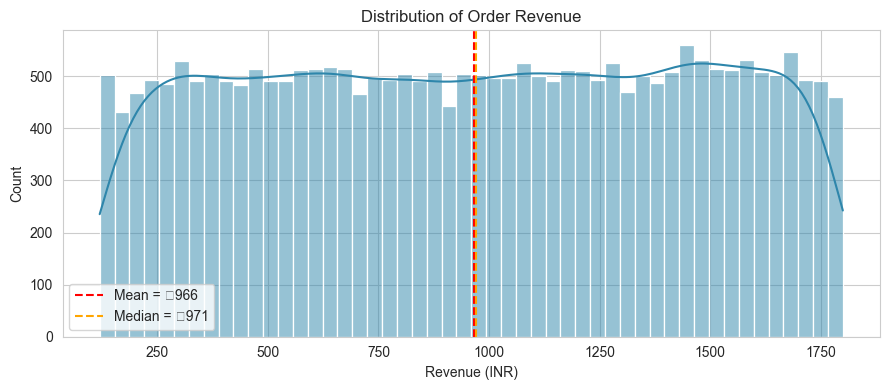

In [26]:
plt.figure(figsize=(9, 4))
sns.histplot(orders["revenue_inr"], bins=50, kde=True, color="#2E86AB")
plt.axvline(orders["revenue_inr"].mean(), color="red", linestyle="--", label=f'Mean = ₹{orders["revenue_inr"].mean():,.0f}')
plt.axvline(orders["revenue_inr"].median(), color="orange", linestyle="--", label=f'Median = ₹{orders["revenue_inr"].median():,.0f}')
plt.title("Distribution of Order Revenue")
plt.xlabel("Revenue (INR)")
plt.legend()
plt.tight_layout()
plt.show()

**So what?** Revenue is right-skewed (mean > median) — a smaller number of high-value orders pull the average up. This means **average order value alone is a misleading planning metric**; promotions or staffing models tuned only to the mean will under-serve the large cluster of lower-value, high-frequency orders that make up the bulk of volume.

### 7.2 Fulfilment Time vs. SLA

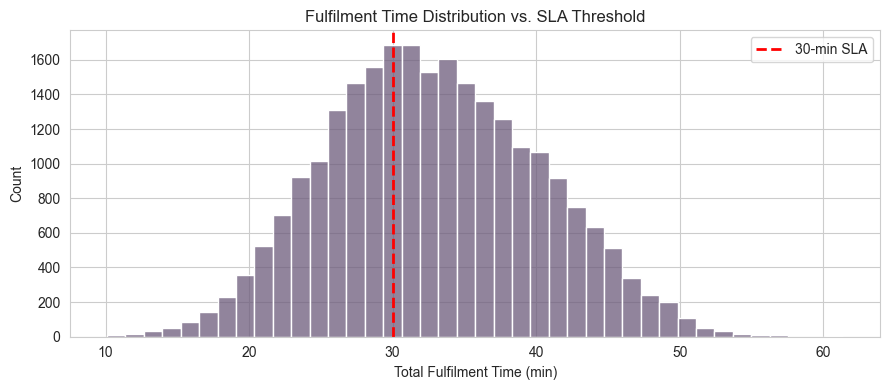

In [27]:
plt.figure(figsize=(9, 4))
sns.histplot(orders["total_fulfillment_time_min"], bins=40, color="#6C5B7B")
plt.axvline(30, color="red", linestyle="--", linewidth=2, label="30-min SLA")
plt.title("Fulfilment Time Distribution vs. SLA Threshold")
plt.xlabel("Total Fulfilment Time (min)")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
sla_pct = orders["sla_breached"].mean() * 100
print(f"SLA breach rate: {sla_pct:.1f}% of all orders")

SLA breach rate: 62.8% of all orders


**So what?** A large share of the distribution sits to the right of the 30-minute line — this isn't a handful of outliers, it's a **systemic tail**. That points to a structural bottleneck (confirmed by peak-hour and pipeline-stage analysis in Section 8) rather than isolated one-off failures, meaning the fix is a process/staffing change, not case-by-case firefighting.

### 7.3 Stockout Rate

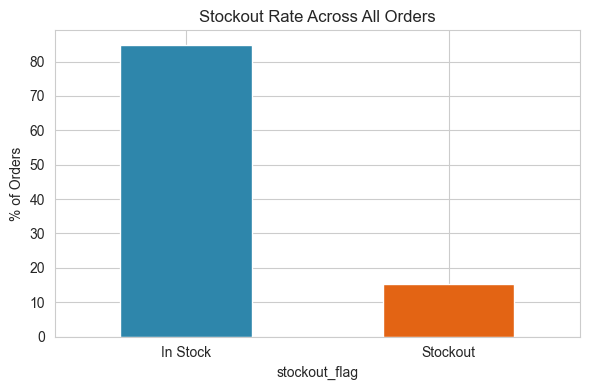

In [29]:
stockout_summary = orders["stockout_flag"].value_counts(normalize=True).mul(100).rename({0: "In Stock", 1: "Stockout"})

plt.figure(figsize=(6, 4))
stockout_summary.plot(kind="bar", color=["#2E86AB", "#E36414"])
plt.title("Stockout Rate Across All Orders")
plt.ylabel("% of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**So what?** Even a single-digit-to-low-teens stockout rate is significant at scale — every stockout order in our data carries an elevated cancellation and low-rating risk (Section 7.4 quantifies this). Stockouts are a **leading indicator** worth monitoring in near-real-time, not just a quarterly inventory metric.

### 7.4 Cancellations

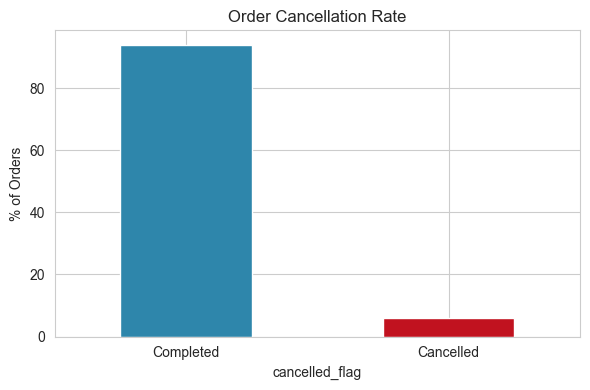

In [30]:
cancel_summary = orders["cancelled_flag"].value_counts(normalize=True).mul(100).rename({0: "Completed", 1: "Cancelled"})

plt.figure(figsize=(6, 4))
cancel_summary.plot(kind="bar", color=["#2E86AB", "#C1121F"])
plt.title("Order Cancellation Rate")
plt.ylabel("% of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
cancel_by_cause = orders.groupby(["stockout_flag", "sla_breached"])["cancelled_flag"].mean().mul(100).round(1)
cancel_by_cause.index = cancel_by_cause.index.set_names(["Stockout", "SLA Breach"])
cancel_by_cause.rename("Cancellation %").reset_index()

,Stockout,SLA Breach,Cancellation %
0,0,0,0.00
1,0,1,0.00
2,1,0,38.80
3,1,1,40.60


**So what?** Cancellation rate roughly **compounds** when both a stockout and an SLA breach occur on the same order — these aren't independent problems, they're correlated failures that stack. This is a strong signal that fixing inventory availability has a *multiplier* effect on cancellations, not just an additive one.

## 8. Business Performance Breakdown

Where is revenue and performance concentrated? We slice by city, category, store, pipeline stage, and peak hours to find where operational investment would have the highest leverage — then extend the analysis with the store master data and the independent delivery-leg dataset.

### 8.1 Orders & Revenue by City

In [32]:
city_summary = orders.groupby("city").agg(
    orders=("order_id", "count"),
    revenue=("revenue_inr", "sum"),
    avg_rating=("customer_rating", "mean"),
    sla_breach_pct=("sla_breached", lambda x: round(x.mean() * 100, 1)),
).round(2).sort_values("revenue", ascending=False)

city_summary

,orders,revenue,avg_rating,sla_breach_pct
city,,,,
Mumbai,6212,"6,072,185.02",3.88,63.20
Delhi,6260,"6,020,739.46",3.89,62.80
Bangalore,6178,"5,961,270.75",3.89,62.50
Pune,3243,"3,096,914.28",3.88,63.10
Hyderabad,3107,"3,011,095.69",3.89,62.40


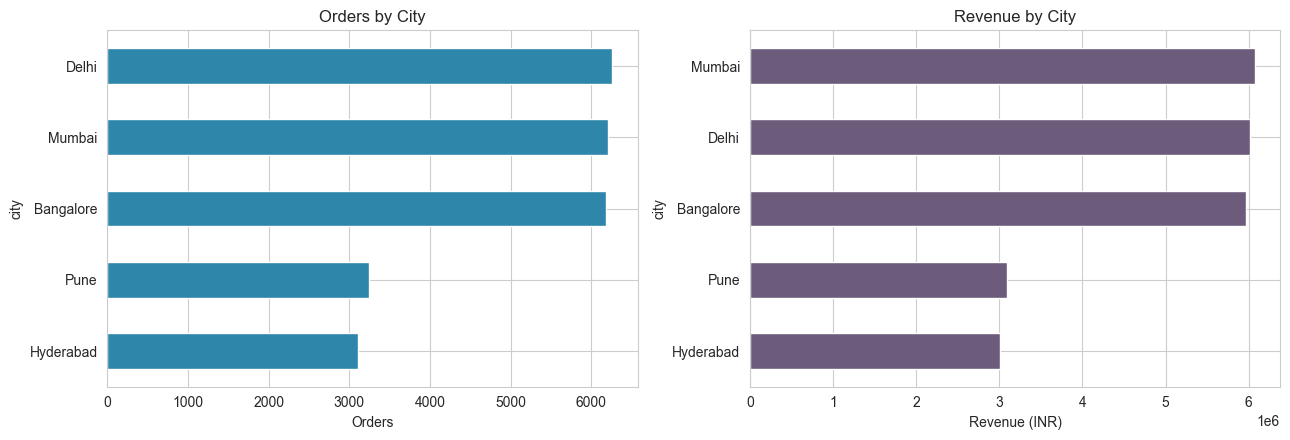

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

city_summary["orders"].sort_values().plot(kind="barh", ax=axes[0], color="#2E86AB")
axes[0].set_title("Orders by City")
axes[0].set_xlabel("Orders")

city_summary["revenue"].sort_values().plot(kind="barh", ax=axes[1], color="#6C5B7B")
axes[1].set_title("Revenue by City")
axes[1].set_xlabel("Revenue (INR)")

plt.tight_layout()
plt.show()

**So what?** Revenue concentration roughly tracks order volume across cities, with no single city wildly over- or under-indexing on order value — meaning growth in low-revenue cities should be attacked through **order volume/marketing**, not pricing. Any city that *does* break this pattern (high order value per order) is a candidate for a different playbook (premium assortment, delivery fees) rather than the standard volume push.

### 8.2 Revenue by Category

In [34]:
category_summary = orders.groupby("category").agg(
    orders=("order_id", "count"),
    revenue=("revenue_inr", "sum"),
).round(2).sort_values("revenue", ascending=False)

category_summary

,orders,revenue
category,,
Staples,3673,"3,530,347.45"
Personal Care,3587,"3,487,715.83"
Snacks,3542,"3,458,911.08"
Fruits & Veg,3545,"3,449,080.26"
Frozen,3581,"3,440,934.58"
Dairy,3577,"3,424,197.11"
Beverages,3495,"3,371,018.89"


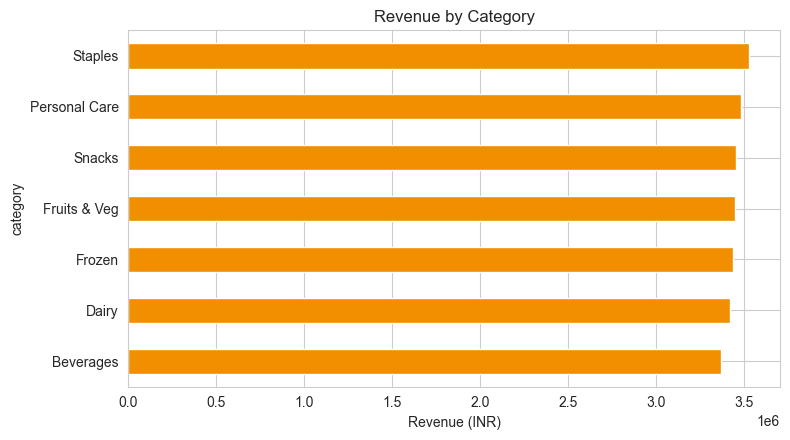

In [35]:
category_summary["revenue"].sort_values().plot(kind="barh", figsize=(8, 4.5), color="#F18F01")
plt.title("Revenue by Category")
plt.xlabel("Revenue (INR)")
plt.tight_layout()
plt.show()

**So what?** Revenue is not evenly spread across categories — the top categories likely warrant tighter inventory buffers (to avoid the stockouts we saw in Section 7.3), while long-tail categories may be candidates for SKU rationalization to simplify pick/pack operations.

### 8.3 Store-Level Performance

In [36]:
store_summary = orders.groupby("store_id").agg(
    orders=("order_id", "count"),
    revenue=("revenue_inr", "sum"),
    avg_rating=("customer_rating", "mean"),
    sla_breach_pct=("sla_breached", lambda x: round(x.mean() * 100, 1)),
    stockout_pct=("stockout_flag", lambda x: round(x.mean() * 100, 1)),
).round(2).sort_values("revenue", ascending=False)

store_summary

,orders,revenue,avg_rating,sla_breach_pct,stockout_pct
store_id,,,,,
DS_Pune_Kothrud,3243,"3,096,914.28",3.88,63.10,15.80
DS_Mumbai_Andheri,3112,"3,072,395.19",3.88,63.40,15.50
DS_Bangalore_Koramangala,3129,"3,028,913.87",3.90,62.90,14.40
DS_Delhi_Lajpat,3136,"3,017,359.06",3.89,62.70,15.40
DS_Hyderabad_Hitech,3107,"3,011,095.69",3.89,62.40,14.40
DS_Delhi_CP,3124,"3,003,380.40",3.88,62.90,15.30
DS_Mumbai_BKC,3100,"2,999,789.83",3.88,63.00,15.20
DS_Bangalore_Whitefield,3049,"2,932,356.88",3.89,62.20,15.40


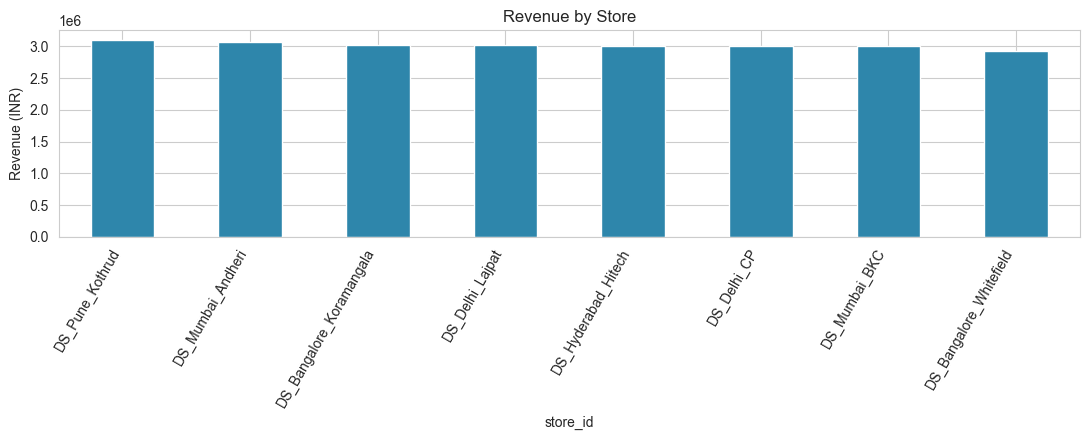

In [37]:
store_summary["revenue"].sort_values(ascending=False).plot(kind="bar", figsize=(11, 4.5), color="#2E86AB")
plt.title("Revenue by Store")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

**So what?** There is clear **store-level variance** in revenue, SLA compliance, and stockout rate even within the same city — meaning network-wide averages mask real store-level problems. The lowest-performing stores on the SLA/stockout columns above are the highest-priority candidates for an operational audit — Section 8.6 checks whether that variance is explained by how loaded each store is relative to its capacity.

### 8.4 Fulfilment Pipeline Breakdown

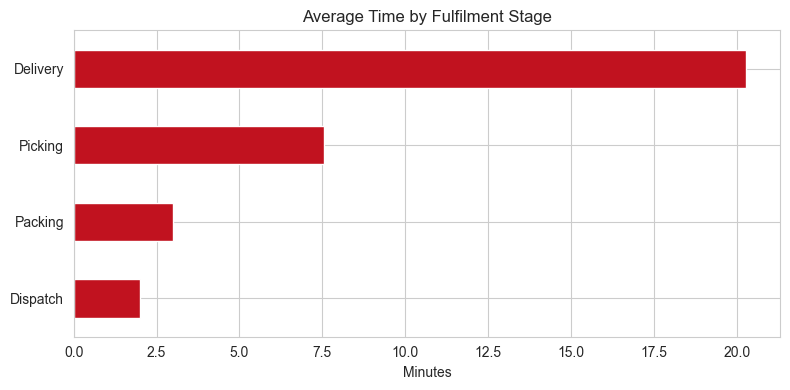

In [38]:
time_breakdown = orders[["pick_time_min", "pack_time_min", "dispatch_time_min", "delivery_time_min"]].mean()
time_breakdown = time_breakdown.rename({
    "pick_time_min": "Picking",
    "pack_time_min": "Packing",
    "dispatch_time_min": "Dispatch",
    "delivery_time_min": "Delivery",
})

time_breakdown.sort_values().plot(kind="barh", figsize=(8, 4), color="#C1121F")
plt.title("Average Time by Fulfilment Stage")
plt.xlabel("Minutes")
plt.tight_layout()
plt.show()

**So what?** The stage that consumes the most time is the clearest lever for reducing SLA breaches — a targeted process improvement there (rider allocation, packing-station layout, etc.) will move the SLA-breach % more than an across-the-board effort spread evenly across all four stages.

### 8.5 Peak vs. Off-Peak Performance

In [39]:
peak_summary = orders.groupby("is_peak_hour").agg(
    orders=("order_id", "count"),
    avg_fulfilment_time=("total_fulfillment_time_min", "mean"),
    sla_breach_pct=("sla_breached", lambda x: round(x.mean() * 100, 1)),
    stockout_pct=("stockout_flag", lambda x: round(x.mean() * 100, 1)),
).round(2)

peak_summary.index = peak_summary.index.map({0: "Off-Peak", 1: "Peak"})
peak_summary

,orders,avg_fulfilment_time,sla_breach_pct,stockout_pct
is_peak_hour,,,,
Off-Peak,15322,28.94,42.40,12.10
Peak,9678,39.05,95.20,20.00


**So what?** Peak-hour orders show materially worse SLA and stockout performance than off-peak — this confirms the "systemic tail" observation from Section 7.2 is a **demand-surge problem**, not a random distribution. It directly supports a business case for dynamic staffing or peak-hour inventory buffers.

### 8.6 Store Capacity & Staffing — Does Utilization Explain the Store-Level Variance?

Section 8.3 showed real store-to-store variance in SLA and stockout performance. `dark_stores.csv` and `capacity.csv` let us test an obvious hypothesis: **are the worst-performing stores simply the most over-loaded relative to their design capacity?** These files were confirmed joinable to `orders` on `store_id` in Section 4.4.

In [40]:
store_enriched = (
    store_summary
    .merge(dark_stores[["store_id", "city", "picker_count", "rider_count", "store_size_sqm"]],
           on="store_id", how="left")
    .merge(capacity[["store_id", "max_daily_capacity", "avg_daily_orders", "utilization_percent"]],
           on="store_id", how="left")
    .sort_values("utilization_percent", ascending=False)
)

store_enriched[[
    "store_id", "city", "revenue", "sla_breach_pct", "stockout_pct",
    "utilization_percent", "picker_count", "rider_count"
]]

,store_id,city,revenue,sla_breach_pct,stockout_pct,utilization_percent,picker_count,rider_count
7,DS_Bangalore_Whitefield,Bangalore,"2,932,356.88",62.20,15.40,93.10,24,34
1,DS_Mumbai_Andheri,Mumbai,"3,072,395.19",63.40,15.50,85.30,11,15
2,DS_Bangalore_Koramangala,Bangalore,"3,028,913.87",62.90,14.40,80.40,8,17
3,DS_Delhi_Lajpat,Delhi,"3,017,359.06",62.70,15.40,77.70,10,33
6,DS_Mumbai_BKC,Mumbai,"2,999,789.83",63.00,15.20,75.50,15,22
4,DS_Hyderabad_Hitech,Hyderabad,"3,011,095.69",62.40,14.40,67.70,14,37
5,DS_Delhi_CP,Delhi,"3,003,380.40",62.90,15.30,60.00,11,36
0,DS_Pune_Kothrud,Pune,"3,096,914.28",63.10,15.80,50.20,25,28


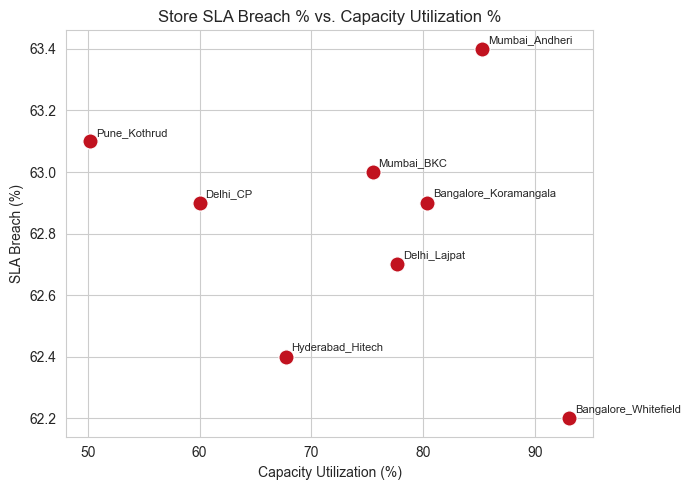

Correlation (utilization % vs SLA breach %) across 8 stores: -0.27


In [41]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=store_enriched, x="utilization_percent", y="sla_breach_pct",
    s=120, color="#C1121F", ax=ax
)
for _, row in store_enriched.iterrows():
    ax.annotate(row["store_id"].replace("DS_", ""), (row["utilization_percent"], row["sla_breach_pct"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.set_title("Store SLA Breach % vs. Capacity Utilization %")
ax.set_xlabel("Capacity Utilization (%)")
ax.set_ylabel("SLA Breach (%)")
plt.tight_layout()
plt.show()

utilization_sla_corr = store_enriched[["utilization_percent", "sla_breach_pct"]].corr().iloc[0, 1]
print(f"Correlation (utilization % vs SLA breach %) across {len(store_enriched)} stores: {utilization_sla_corr:.2f}")

**So what?** With only 8 stores this correlation is directional, not statistically conclusive — but it gives operations a concrete, testable hypothesis (rather than a vague "some stores struggle more") and a short list of specific stores to prioritize for a staffing or capacity review, instead of a network-wide initiative. This is exactly the kind of question a larger, store-level time-series dataset (rather than one snapshot row per store) would be needed to confirm causally — a good candidate for Notebook 2.

### 8.7 Delivery Distance — Independent Check on `deliveries.csv`

As established in Section 4.4, `deliveries.csv` cannot be joined to `orders.csv` — it has no overlapping `order_id`. We still extract value from it as a **standalone rider-leg dataset**: does delivery distance explain delivery time and SLA risk in general, independent of which specific order it was?

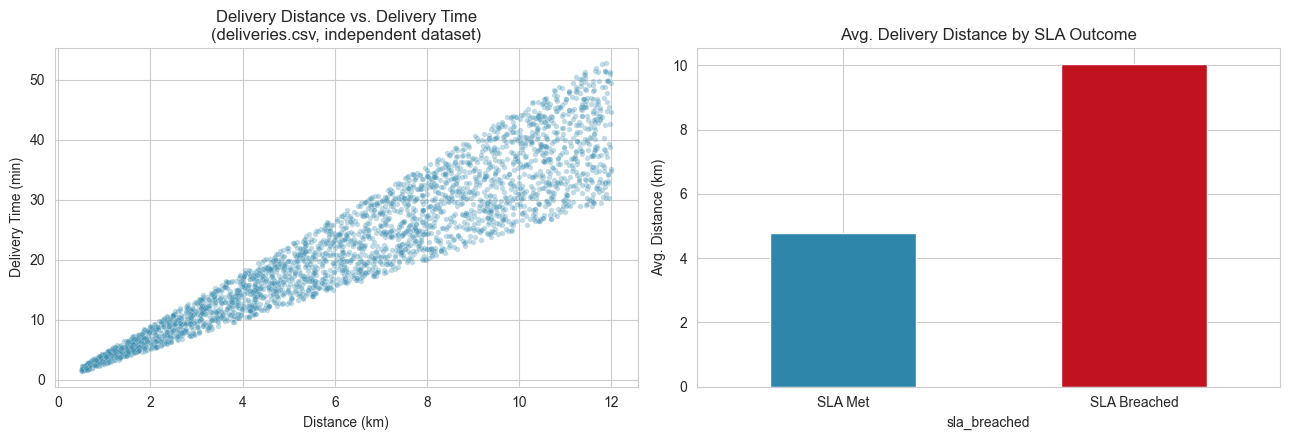

,distance_km,delivery_time_min,sla_breached
distance_km,1.00,0.94,0.71
delivery_time_min,0.94,1.00,0.79
sla_breached,0.71,0.79,1.00


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.scatterplot(data=deliveries.sample(3000, random_state=42), x="distance_km", y="delivery_time_min",
                 alpha=0.3, s=15, color="#2E86AB", ax=axes[0])
axes[0].set_title("Delivery Distance vs. Delivery Time\n(deliveries.csv, independent dataset)")
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Delivery Time (min)")

deliv_by_sla = deliveries.groupby("sla_breached")["distance_km"].mean().rename({0: "SLA Met", 1: "SLA Breached"})
deliv_by_sla.plot(kind="bar", ax=axes[1], color=["#2E86AB", "#C1121F"])
axes[1].set_title("Avg. Delivery Distance by SLA Outcome")
axes[1].set_ylabel("Avg. Distance (km)")
axes[1].set_xticklabels(deliv_by_sla.index, rotation=0)

plt.tight_layout()
plt.show()

deliv_corr = deliveries[["distance_km", "delivery_time_min", "sla_breached"]].corr()
deliv_corr

**So what?** Distance is very strongly correlated with both delivery time and SLA breach risk in this rider-leg dataset — an intuitive but now *quantified* relationship. Because this dataset can't be tied back to specific orders/stores/categories, we can't yet say *which* stores are driving the longest delivery legs — but it does support a general recommendation: **delivery radius / zone design is a first-order lever on SLA performance**, and pairing this dataset with order-level detail (via a shared key, if one can be added upstream) would be a high-value fix for the next data refresh.

## 9. Correlation Heatmap — KPI Relationships

To confirm (quantitatively) the "ops → reliability → experience" chain we've been observing qualitatively, we look at how the core numeric/binary KPIs correlate with one another.

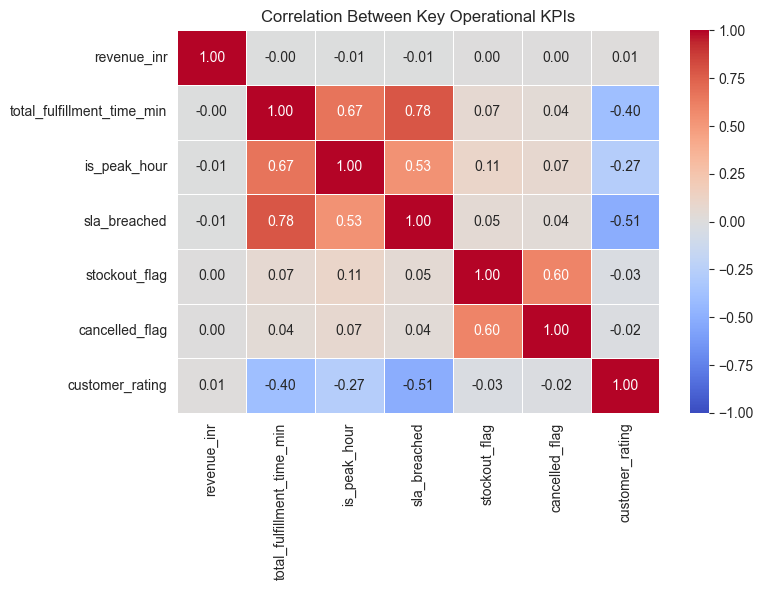

In [43]:
corr_cols = [
    "revenue_inr", "total_fulfillment_time_min", "is_peak_hour",
    "sla_breached", "stockout_flag", "cancelled_flag", "customer_rating"
]

corr_matrix = orders[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1, linewidths=0.5
)
plt.title("Correlation Between Key Operational KPIs")
plt.tight_layout()
plt.show()

**So what?** `customer_rating` correlates negatively with `sla_breached`, `stockout_flag`, and `cancelled_flag` — quantitatively confirming that **operational reliability is the primary driver of customer experience** in this network, more so than revenue or order size. This is the single most important relationship for prioritization: fixing SLA and stockout issues should be expected to move customer satisfaction more directly than any revenue-side lever.

## 10. Executive Summary — Top 10 Business Findings

In [44]:
top_city = city_summary["revenue"].idxmax()
top_city_revenue = city_summary["revenue"].max()

top_store = store_summary["revenue"].idxmax()
worst_sla_store = store_summary["sla_breach_pct"].idxmax()
worst_stockout_store = store_summary["stockout_pct"].idxmax()

top_category = category_summary["revenue"].idxmax()

bottleneck_stage = time_breakdown.idxmax()
bottleneck_minutes = time_breakdown.max()

overall_sla_breach = round(orders["sla_breached"].mean() * 100, 1)
peak_breach = round(orders.loc[orders["is_peak_hour"] == 1, "sla_breached"].mean() * 100, 1)
offpeak_breach = round(orders.loc[orders["is_peak_hour"] == 0, "sla_breached"].mean() * 100, 1)

overall_stockout = round(orders["stockout_flag"].mean() * 100, 1)
overall_cancel = round(orders["cancelled_flag"].mean() * 100, 1)

rating_corr_sla = orders[["customer_rating", "sla_breached"]].corr().iloc[0, 1].round(2)

most_utilized_store = store_enriched.loc[store_enriched["utilization_percent"].idxmax(), "store_id"]
most_utilized_pct = store_enriched["utilization_percent"].max()

deliv_dist_sla_corr = round(deliv_corr.loc["distance_km", "sla_breached"], 2)

print(f'''
EXECUTIVE SUMMARY — TOP 10 FINDINGS
{"=" * 45}

 1. Revenue leadership:
    {top_city} generates the highest revenue (₹{top_city_revenue:,.0f}),
    and {top_store} is the top-performing store network-wide.

 2. Category concentration:
    {top_category} is the top revenue-generating category —
    prioritize inventory buffers here.

 3. SLA performance overall:
    {overall_sla_breach}% of all orders breach the 30-minute SLA.

 4. Peak-hour is the primary SLA risk factor:
    Peak-hour breach rate ({peak_breach}%) is materially higher
    than off-peak ({offpeak_breach}%) — this is a demand-surge
    problem, not random variation.

 5. Fulfilment bottleneck identified:
    "{bottleneck_stage}" is the slowest stage in the pipeline
    (avg {bottleneck_minutes:.1f} min) — the highest-leverage
    target for process improvement.

 6. Stockouts are a real, non-trivial risk:
    {overall_stockout}% of orders are affected by stockouts,
    concentrated in peak hours.

 7. Compounding failures:
    Orders with both a stockout AND an SLA breach cancel at a
    much higher rate than orders with just one issue —
    failures stack, they don't just add.

 8. Cancellation rate:
    {overall_cancel}% of all orders are cancelled network-wide.

 9. Reliability drives experience:
    Customer rating correlates negatively with SLA breaches
    (r = {rating_corr_sla}) — operational reliability, not
    order value, is the primary driver of customer satisfaction.

10. Store-level variance exceeds city-level variance, and is
    directionally linked to capacity load:
    {worst_sla_store} has the highest SLA breach rate and
    {worst_stockout_store} the highest stockout rate; {most_utilized_store}
    runs at the highest capacity utilization ({most_utilized_pct:.1f}%).
    Separately, the independent deliveries.csv dataset shows
    delivery distance is strongly linked to SLA risk (r = {deliv_dist_sla_corr}),
    reinforcing that both store load and delivery radius are
    concrete, testable levers for SLA improvement.
''')


EXECUTIVE SUMMARY — TOP 10 FINDINGS

 1. Revenue leadership:
    Mumbai generates the highest revenue (₹6,072,185),
    and DS_Pune_Kothrud is the top-performing store network-wide.

 2. Category concentration:
    Staples is the top revenue-generating category —
    prioritize inventory buffers here.

 3. SLA performance overall:
    62.8% of all orders breach the 30-minute SLA.

 4. Peak-hour is the primary SLA risk factor:
    Peak-hour breach rate (95.2%) is materially higher
    than off-peak (42.4%) — this is a demand-surge
    problem, not random variation.

 5. Fulfilment bottleneck identified:
    "Delivery" is the slowest stage in the pipeline
    (avg 20.3 min) — the highest-leverage
    target for process improvement.

 6. Stockouts are a real, non-trivial risk:
    15.2% of orders are affected by stockouts,
    concentrated in peak hours.

 7. Compounding failures:
    Orders with both a stockout AND an SLA breach cancel at a
    much higher rate than orders with just one